In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<b><font color="red" size="6">08_DNN(딥러닝)_MNIST(손글씨데이터)</font></b>

## 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 가져옴
- pip install opencv-contrib-python
- pip show opencv-contrib-python

In [1]:
import numpy as np
import pandas as pd # get_dummies, 원핫인코딩
from tensorflow.keras.datasets import mnist # mnist 데이터셋
from tensorflow.keras import utils
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model # 모델생성
from tensorflow.keras.layers import Input, Dense, Dropout
import matplotlib.pyplot as plt # 학습과정 loss와 acc 시각화

# quiz에서는 scale조정, train_test_split 등을 추가

from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler # 스케일조정
from sklearn.model_selection import train_test_split # 데이터 분리

In [3]:
import numpy as np
data = np.loadtxt('data/mnist_train_small.csv',
                  delimiter=',',
                  skiprows=1,
                  )
data.shape

(100, 785)

타겟 :  5.0
이미지(28*28을 1차원으로) :  AxesImage(size=(28, 28))


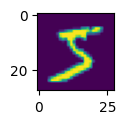

In [4]:
import matplotlib.pyplot as plt
img = data[0, 1:].reshape(28, 28)
print('타겟 : ', data[0,0])
plt.figure(figsize=(1,1))
print('이미지(28*28을 1차원으로) : ', plt.imshow(img) )

In [5]:
for row in data[0, 1:].reshape(28, 28):
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

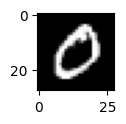

In [6]:
plt.figure(figsize=(1,1))
plt.imshow(data[1, 1:].reshape(28, 28), cmap='gray')

### opencv 설치

In [7]:
# %pip install opencv-contrib-python

Note: you may need to restart the kernel to use updated packages.


In [8]:
# %pip show opencv-contrib-python

Name: opencv-contrib-python
Version: 4.11.0.86
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [9]:
# %pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


#### 칼라사진 -> 흑백모드의 넘파이 배열로
#### opencv 설치
- pip install opencv-contrib-python
- pip show opencv-contrib-python
- pip install opencv-python

In [14]:
# 칼라사진 -> 흑백모드의 넘파이 배열로
import cv2
image_gray = cv2.imread('data/dnntest1.jpg', cv2.IMREAD_GRAYSCALE) # 흑백포멧으로 읽기
print(image_gray.shape)
print(type(image_gray))

(512, 512)
<class 'numpy.ndarray'>


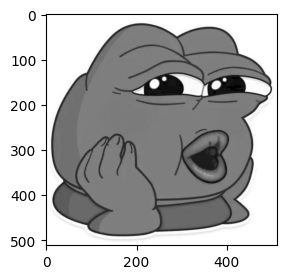

In [18]:
plt.figure(figsize=(3,3))
plt.imshow(image_gray, cmap='gray')

## 1. 데이터 생성 및 전처리

In [69]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [70]:
print(y_train[0]) #타겟변수
for row in X_train[0]:
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

5
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0

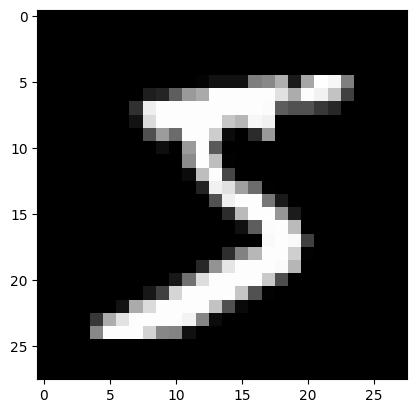

In [71]:
plt.imshow(X_train[0], cmap='gray')

#### 학습셋(6만개) -> 훈련셋(5만개) + 검증셋(만개)로 분리

In [72]:
# 학습셋(6만개) -> 훈련셋(5만개) + 검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [73]:
# 학습셋(5만개:fit용), 검증셋(만개:fit용), test셋(만개:평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


#### 입력(독립) 변수 (n, 28,28) -> n, 784 -> 실수형변환 -> 스케일조정(255.0으로 나눠)

In [74]:
# train_input = train_input / 255.0  # 모든 픽셀의 값을 0~255에서 0~1로 변경
# test_input = test_input / 255
# train_input = train_input.reshape(-1, 28*28)  # 3차원을 2차원으로 변경
# test_input = test_input.reshape(-1, 28*28)

# print(f"train_input_shape: {train_input.shape}")  # train_input_shape: (60000, 784)
# print(f"test_input_shape: {test_input.shape}")  # test_input_shape: (10000, 784)
# [출처] 딥러닝 - DNN으로 MNIST 손글씨 분류하기 (TensorFlow 2.0)|작성자 행자

In [75]:
# 입력(독립) 변수 (n, 28,28) -> n, 784 -> 실수형변환 -> 스케일조정(255.0으로 나눠)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
train_X[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [76]:
val_X= X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [77]:
# 훈련셋 5만개 -> 700개만 뽑고, 테스트셋 1만개 -> 300개만 추출 (목적 : 학습시간 절약), 테스트셋은 그대로
train_idx = np.random.choice(50000, 700) # 0부터 44사이에 6개를 뽑아
val_idx = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]

train_X.shape, y_train.shape, val_X.shape, y_val.shape, X_test.shape, y_test.shape

((700, 784), (700,), (300, 784), (300,), (10000, 28, 28), (10000,))

In [83]:
#타겟(종속) 변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
print(y_train[:2]) #원핫인코딩 전
print(train_Y[:2]) #원핫인코딩 후

[9 0]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## 데이터 전처리 전체과정 
- 위에 학습셋부터 코드 모아놓은 거(이것만 실행하면됨)

In [85]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape
# 학습셋(6만개) -> 훈련셋(5만개) + 검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

# 입력(독립) 변수 (n, 28,28) -> n, 784 -> 실수형변환 -> 스케일조정(255.0으로 나눠)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X= X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

# 훈련셋 5만개 -> 700개만 뽑고, 테스트셋 1만개 -> 300개만 추출 (목적 : 학습시간 절약), 테스트셋은 그대로
train_idx = np.random.choice(50000, 700) # 0부터 44사이에 6개를 뽑아
val_idx = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X = val_X[val_idx]
y_val = y_val[val_idx]

#타겟(종속) 변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)

train_X.shape, y_train.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((700, 784), (700,), (300, 784), (300, 10), (10000, 784), (10000, 10))

## 2. 모델구성

In [86]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(2, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 1570      
                                                                 
 dense_1 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 3.학습과정 설정

In [87]:
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
              optimizer='adam',
              metrics=['accuracy'])

In [88]:
%%time
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
#                 verbose=
                )

Epoch 1/500
7/7 [==============================] - 1s 34ms/step - loss: 2.2967 - accuracy: 0.1371 - val_loss: 2.2986 - val_accuracy: 0.1667
Epoch 2/500
7/7 [==============================] - 0s 8ms/step - loss: 2.2608 - accuracy: 0.1814 - val_loss: 2.2650 - val_accuracy: 0.1567
Epoch 3/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2144 - accuracy: 0.2200 - val_loss: 2.2385 - val_accuracy: 0.1533
Epoch 4/500
7/7 [==============================] - 0s 9ms/step - loss: 2.1686 - accuracy: 0.2343 - val_loss: 2.2122 - val_accuracy: 0.1667
Epoch 5/500
7/7 [==============================] - 0s 8ms/step - loss: 2.1236 - accuracy: 0.2400 - val_loss: 2.1835 - val_accuracy: 0.1733
Epoch 6/500
7/7 [==============================] - 0s 8ms/step - loss: 2.0857 - accuracy: 0.2571 - val_loss: 2.1604 - val_accuracy: 0.1867
Epoch 7/500
7/7 [==============================] - 0s 7ms/step - loss: 2.0540 - accuracy: 0.2486 - val_loss: 2.1339 - val_accuracy: 0.2067
Epoch 8/500
7/7 [=========

7/7 [==============================] - 0s 7ms/step - loss: 1.3088 - accuracy: 0.5414 - val_loss: 1.5755 - val_accuracy: 0.4367
Epoch 118/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3044 - accuracy: 0.5457 - val_loss: 1.5701 - val_accuracy: 0.4333
Epoch 119/500
7/7 [==============================] - 0s 7ms/step - loss: 1.3015 - accuracy: 0.5471 - val_loss: 1.5641 - val_accuracy: 0.4300
Epoch 120/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2980 - accuracy: 0.5471 - val_loss: 1.5631 - val_accuracy: 0.4333
Epoch 121/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2949 - accuracy: 0.5457 - val_loss: 1.5641 - val_accuracy: 0.4333
Epoch 122/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2920 - accuracy: 0.5500 - val_loss: 1.5631 - val_accuracy: 0.4333
Epoch 123/500
7/7 [==============================] - 0s 7ms/step - loss: 1.2890 - accuracy: 0.5543 - val_loss: 1.5594 - val_accuracy: 0.4433
Epoch 124/500
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 1.0471 - accuracy: 0.6229 - val_loss: 1.4475 - val_accuracy: 0.4800
Epoch 234/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0454 - accuracy: 0.6229 - val_loss: 1.4481 - val_accuracy: 0.4833
Epoch 235/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0435 - accuracy: 0.6214 - val_loss: 1.4520 - val_accuracy: 0.4767
Epoch 236/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0421 - accuracy: 0.6200 - val_loss: 1.4499 - val_accuracy: 0.4767
Epoch 237/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0405 - accuracy: 0.6214 - val_loss: 1.4490 - val_accuracy: 0.4800
Epoch 238/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0390 - accuracy: 0.6257 - val_loss: 1.4474 - val_accuracy: 0.4867
Epoch 239/500
7/7 [==============================] - 0s 7ms/step - loss: 1.0377 - accuracy: 0.6286 - val_loss: 1.4466 - val_accuracy: 0.4867
Epoch 240/500
7/7 [========

7/7 [==============================] - 0s 11ms/step - loss: 0.8968 - accuracy: 0.6729 - val_loss: 1.4415 - val_accuracy: 0.5367
Epoch 350/500
7/7 [==============================] - 0s 10ms/step - loss: 0.8954 - accuracy: 0.6757 - val_loss: 1.4420 - val_accuracy: 0.5367
Epoch 351/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8944 - accuracy: 0.6800 - val_loss: 1.4431 - val_accuracy: 0.5333
Epoch 352/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8930 - accuracy: 0.6800 - val_loss: 1.4424 - val_accuracy: 0.5433
Epoch 353/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8922 - accuracy: 0.6771 - val_loss: 1.4419 - val_accuracy: 0.5400
Epoch 354/500
7/7 [==============================] - 0s 10ms/step - loss: 0.8909 - accuracy: 0.6800 - val_loss: 1.4413 - val_accuracy: 0.5400
Epoch 355/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8901 - accuracy: 0.6771 - val_loss: 1.4466 - val_accuracy: 0.5333
Epoch 356/500
7/7 [=====

7/7 [==============================] - 0s 6ms/step - loss: 0.7885 - accuracy: 0.7300 - val_loss: 1.5176 - val_accuracy: 0.5300
Epoch 466/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7873 - accuracy: 0.7343 - val_loss: 1.5247 - val_accuracy: 0.5267
Epoch 467/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7870 - accuracy: 0.7357 - val_loss: 1.5227 - val_accuracy: 0.5267
Epoch 468/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7865 - accuracy: 0.7329 - val_loss: 1.5168 - val_accuracy: 0.5233
Epoch 469/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7853 - accuracy: 0.7343 - val_loss: 1.5242 - val_accuracy: 0.5267
Epoch 470/500
7/7 [==============================] - 0s 7ms/step - loss: 0.7842 - accuracy: 0.7357 - val_loss: 1.5246 - val_accuracy: 0.5267
Epoch 471/500
7/7 [==============================] - 0s 9ms/step - loss: 0.7839 - accuracy: 0.7329 - val_loss: 1.5231 - val_accuracy: 0.5267
Epoch 472/500
7/7 [========

In [89]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

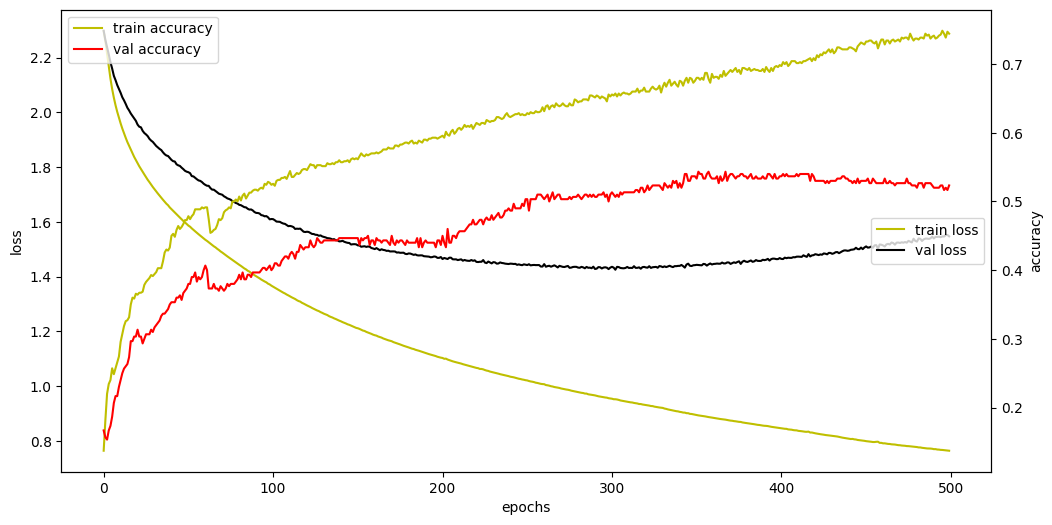

In [90]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')


acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'y', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'r', label='val accuracy')

loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')

loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

## 4. 모델 평가하기

In [92]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

100/100 [==============================] - 0s 1ms/step - loss: 1.5334 - accuracy: 0.5304
loss : 1.533393383026123
accuracy : 0.5303999781608582


# DNN(위에서한것)의 accuracy 늘리기
- 데이터 확보
- 레이어 추가
- 과적합 방지(validation data추가, dropout, 활성화함수, tanh)
- epochs 조정
- optimizer 변경

Epoch 1/100
100/100 [==============================] - 1s 7ms/step - loss: 0.7887 - accuracy: 0.7642 - val_loss: 0.3310 - val_accuracy: 0.9057
Epoch 2/100
100/100 [==============================] - 0s 4ms/step - loss: 0.2794 - accuracy: 0.9197 - val_loss: 0.2358 - val_accuracy: 0.9333
Epoch 3/100
100/100 [==============================] - 0s 4ms/step - loss: 0.1906 - accuracy: 0.9465 - val_loss: 0.2137 - val_accuracy: 0.9410
Epoch 4/100
100/100 [==============================] - 0s 4ms/step - loss: 0.1490 - accuracy: 0.9569 - val_loss: 0.1877 - val_accuracy: 0.9493
Epoch 5/100
100/100 [==============================] - 0s 4ms/step - loss: 0.1129 - accuracy: 0.9689 - val_loss: 0.1847 - val_accuracy: 0.9517
Epoch 6/100
100/100 [==============================] - 0s 4ms/step - loss: 0.0867 - accuracy: 0.9749 - val_loss: 0.1879 - val_accuracy: 0.9497
Epoch 7/100
100/100 [==============================] - 0s 4ms/step - loss: 0.0674 - accuracy: 0.9817 - val_loss: 0.1742 - val_accuracy: 0.9543

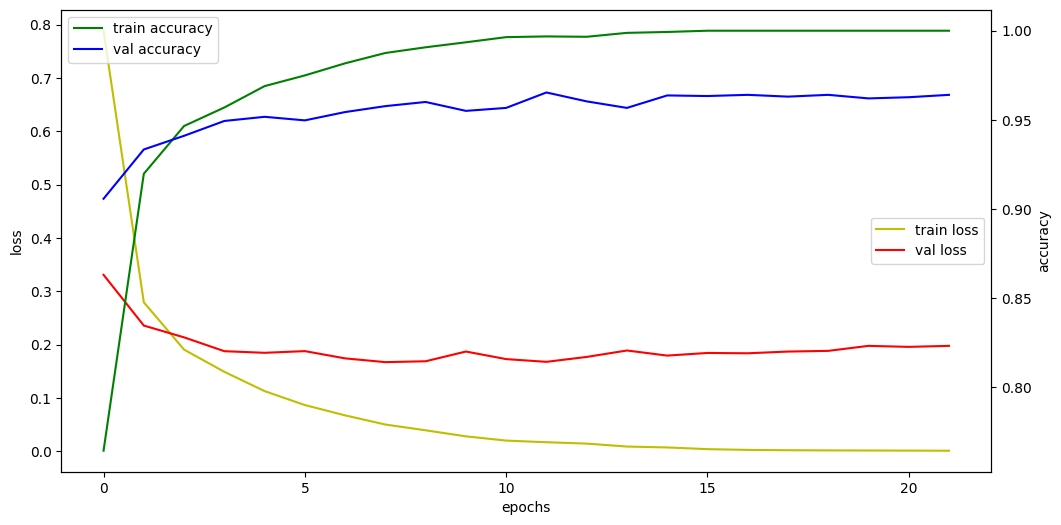

loss : 0.1809898167848587
accuracy : 0.9546999931335449
CPU times: total: 22.5 s
Wall time: 11.4 s


In [2]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 10000)
val_idx  = np.random.choice(10000, 3000)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))


# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])
# 학습
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

hist = model.fit(train_X, train_Y,
                epochs=100,
                batch_size=100,
                callbacks=[early_stop],
                validation_data=(val_X, val_Y),
                verbose=1)
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

#### 실제값 & 예측값

In [3]:
# 실제값
test_Y.argmax(axis=1) == y_test

array([ True,  True,  True, ...,  True,  True,  True])

In [4]:
# 예측값
yhat = model.predict(test_X).argmax(axis=1)
yhat = np.argmax(model.predict(test_X), axis=1)
yhat

313/313 [==============================] - 0s 1ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

#### crosstab, confusion_matrix(교차표)

In [5]:
pd.crosstab(y_test, yhat)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,963,0,2,3,1,1,6,1,3,0
1,0,1116,2,2,0,1,5,2,7,0
2,5,4,956,30,9,1,4,11,12,0
3,1,1,6,971,1,8,1,7,10,4
4,1,0,3,1,941,2,4,3,5,22
5,9,0,1,14,2,847,11,1,3,4
6,7,4,2,1,9,5,928,1,1,0
7,0,8,11,14,2,1,0,980,2,10
8,9,2,4,20,7,10,10,8,899,5


In [6]:
confusion_matrix(y_test, yhat)

array([[ 963,    0,    2,    3,    1,    1,    6,    1,    3,    0],
       [   0, 1116,    2,    2,    0,    1,    5,    2,    7,    0],
       [   5,    4,  956,   30,    9,    1,    4,   11,   12,    0],
       [   1,    1,    6,  971,    1,    8,    1,    7,   10,    4],
       [   1,    0,    3,    1,  941,    2,    4,    3,    5,   22],
       [   9,    0,    1,   14,    2,  847,   11,    1,    3,    4],
       [   7,    4,    2,    1,    9,    5,  928,    1,    1,    0],
       [   0,    8,   11,   14,    2,    1,    0,  980,    2,   10],
       [   9,    2,    4,   20,    7,   10,   10,    8,  899,    5],
       [   8,    4,    1,   15,   17,    2,    0,   10,    6,  946]],
      dtype=int64)

In [7]:
# 틀린 갯수 :
10000 - 10000*loss_and_metrics[1]

453.0000686645508

In [8]:
cnt=0
for y, h in zip(y_test, yhat):
    if y!=h:
        cnt += 1
print('틀린 갯수 :', cnt)

틀린 갯수 : 453


In [9]:
# 모델 저장
model.save('model/08_mnist.ht')

INFO:tensorflow:Assets written to: model/08_mnist.ht\assets


# ※ 콜백함수1 : 로그출력

In [10]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [12]:
%%time
# 매번 로그 출력하면 지저분해 질 수 있으니, 특정 에포크마다 로그 출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}) : # 1 epoch마다 자동 실행되는 함수
        self.epoch += 1  # epoch마다 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{}'.\
                  format(self.epoch, 
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')
                  )
            )
        
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
customHistory = CustomHistory()
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistory]) # 콜백함수

epoch:10, loss:2.103760004043579, acc:0.238571435213089, val_loss:2.1122069358825684, val_acc:0.23666666448116302
epoch:20, loss:1.9445197582244873, acc:0.2800000011920929, val_loss:1.9744791984558105, val_acc:0.2666666805744171
epoch:30, loss:1.8208116292953491, acc:0.36142855882644653, val_loss:1.8686600923538208, val_acc:0.3766666650772095
epoch:40, loss:1.7206614017486572, acc:0.427142858505249, val_loss:1.7840964794158936, val_acc:0.4166666567325592
epoch:50, loss:1.6359343528747559, acc:0.43714284896850586, val_loss:1.713719129562378, val_acc:0.43666666746139526
CPU times: total: 4.48 s
Wall time: 3.41 s


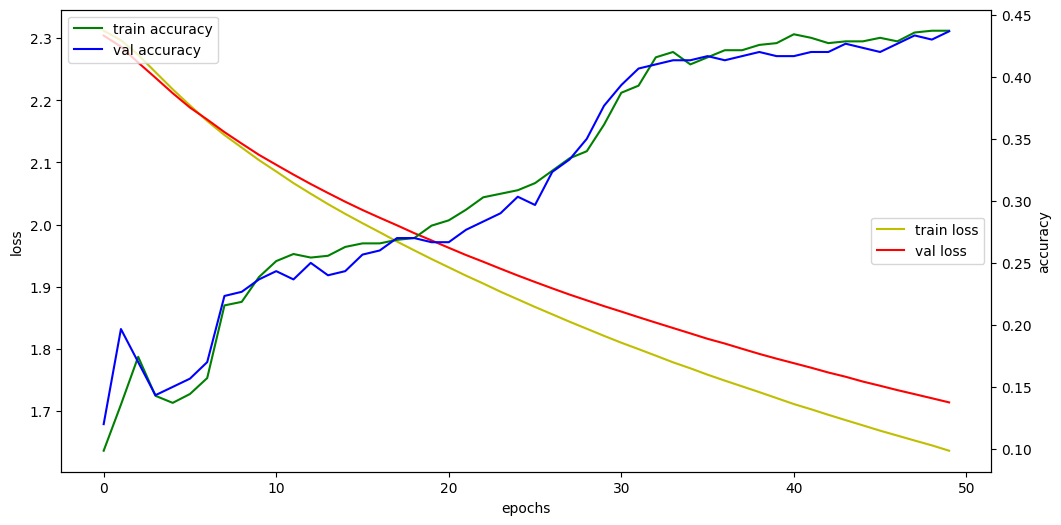

In [13]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# ※콜백함수2 : EarlyStopping
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [14]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=2) 
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping]) # 콜백함수

Epoch 1/500
7/7 [==============================] - 1s 28ms/step - loss: 2.3099 - accuracy: 0.1457 - val_loss: 2.3018 - val_accuracy: 0.1500
Epoch 2/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2946 - accuracy: 0.1400 - val_loss: 2.2896 - val_accuracy: 0.1767
Epoch 3/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2747 - accuracy: 0.1600 - val_loss: 2.2622 - val_accuracy: 0.1800
Epoch 4/500
7/7 [==============================] - 0s 7ms/step - loss: 2.2503 - accuracy: 0.1900 - val_loss: 2.2418 - val_accuracy: 0.1700
Epoch 5/500
7/7 [==============================] - 0s 8ms/step - loss: 2.2280 - accuracy: 0.1757 - val_loss: 2.2259 - val_accuracy: 0.1467


# ※콜백함수3 : ModelCheckpoint
- epoch마다 val_accuracy(val_loss, accuracy, loss)값이 좋을 때 모델을 자동 저장하는 콜백

In [15]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=10) 
# 모델 자동 저장 콜백
import os
model_save_folder = './model08/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'

checkpoint = ModelCheckpoint(filepath=file, 
                            monitor='val_accuracy', # 모리터할 지표
                            save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                            mode = 'max', # 값이 클수록 저장
                            verbose=1 # 저장시 로그 출력
                            )

hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping, checkpoint]) # 콜백함수

Epoch 1/500
1/7 [===>..........................] - ETA: 3s - loss: 2.3092 - accuracy: 0.0800
Epoch 1: val_accuracy improved from -inf to 0.15000, saving model to ./model08\mnist-001-val0.1500.h5
7/7 [==============================] - 1s 34ms/step - loss: 2.3043 - accuracy: 0.0829 - val_loss: 2.2910 - val_accuracy: 0.1500
Epoch 2/500
1/7 [===>..........................] - ETA: 0s - loss: 2.3009 - accuracy: 0.1200
Epoch 2: val_accuracy did not improve from 0.15000
7/7 [==============================] - 0s 8ms/step - loss: 2.2858 - accuracy: 0.1057 - val_loss: 2.2703 - val_accuracy: 0.0933
Epoch 3/500
1/7 [===>..........................] - ETA: 0s - loss: 2.2816 - accuracy: 0.0500
Epoch 3: val_accuracy did not improve from 0.15000
7/7 [==============================] - 0s 9ms/step - loss: 2.2636 - accuracy: 0.0957 - val_loss: 2.2516 - val_accuracy: 0.0867
Epoch 4/500
1/7 [===>..........................] - ETA: 0s - loss: 2.2359 - accuracy: 0.1300
Epoch 4: val_accuracy did not improve from

Epoch 29/500
1/7 [===>..........................] - ETA: 0s - loss: 1.7486 - accuracy: 0.3500
Epoch 29: val_accuracy did not improve from 0.30667
7/7 [==============================] - 0s 8ms/step - loss: 1.8104 - accuracy: 0.2743 - val_loss: 1.8581 - val_accuracy: 0.2933
Epoch 30/500
1/7 [===>..........................] - ETA: 0s - loss: 1.8455 - accuracy: 0.2300
Epoch 30: val_accuracy improved from 0.30667 to 0.31333, saving model to ./model08\mnist-030-val0.3133.h5
7/7 [==============================] - 0s 10ms/step - loss: 1.8010 - accuracy: 0.2643 - val_loss: 1.8506 - val_accuracy: 0.3133
Epoch 31/500
1/7 [===>..........................] - ETA: 0s - loss: 1.7599 - accuracy: 0.3200
Epoch 31: val_accuracy did not improve from 0.31333
7/7 [==============================] - 0s 9ms/step - loss: 1.7931 - accuracy: 0.2729 - val_loss: 1.8444 - val_accuracy: 0.3100
Epoch 32/500
1/7 [===>..........................] - ETA: 0s - loss: 1.7657 - accuracy: 0.3100
Epoch 32: val_accuracy did not i

Epoch 57/500
1/7 [===>..........................] - ETA: 0s - loss: 1.5314 - accuracy: 0.4000
Epoch 57: val_accuracy improved from 0.37000 to 0.37667, saving model to ./model08\mnist-057-val0.3767.h5
7/7 [==============================] - 0s 12ms/step - loss: 1.6002 - accuracy: 0.3900 - val_loss: 1.6819 - val_accuracy: 0.3767
Epoch 58/500
1/7 [===>..........................] - ETA: 0s - loss: 1.5088 - accuracy: 0.4600
Epoch 58: val_accuracy did not improve from 0.37667
7/7 [==============================] - 0s 8ms/step - loss: 1.5934 - accuracy: 0.3929 - val_loss: 1.6783 - val_accuracy: 0.3733
Epoch 59/500
1/7 [===>..........................] - ETA: 0s - loss: 1.5750 - accuracy: 0.3200
Epoch 59: val_accuracy did not improve from 0.37667
7/7 [==============================] - 0s 8ms/step - loss: 1.5879 - accuracy: 0.3929 - val_loss: 1.6701 - val_accuracy: 0.3700
Epoch 60/500
1/7 [===>..........................] - ETA: 0s - loss: 1.5174 - accuracy: 0.4300
Epoch 60: val_accuracy did not i

1/7 [===>..........................] - ETA: 0s - loss: 1.4575 - accuracy: 0.4800
Epoch 85: val_accuracy did not improve from 0.42667
7/7 [==============================] - 0s 11ms/step - loss: 1.4447 - accuracy: 0.4571 - val_loss: 1.5680 - val_accuracy: 0.4233
Epoch 86/500
1/7 [===>..........................] - ETA: 0s - loss: 1.4258 - accuracy: 0.5000
Epoch 86: val_accuracy did not improve from 0.42667
7/7 [==============================] - 0s 9ms/step - loss: 1.4397 - accuracy: 0.4643 - val_loss: 1.5641 - val_accuracy: 0.4200
Epoch 87/500
1/7 [===>..........................] - ETA: 0s - loss: 1.4248 - accuracy: 0.5200
Epoch 87: val_accuracy did not improve from 0.42667
7/7 [==============================] - 0s 9ms/step - loss: 1.4342 - accuracy: 0.4571 - val_loss: 1.5619 - val_accuracy: 0.4267
Epoch 88/500
1/7 [===>..........................] - ETA: 0s - loss: 1.4174 - accuracy: 0.4700
Epoch 88: val_accuracy improved from 0.42667 to 0.43333, saving model to ./model08\mnist-088-val0.4

7/7 [==============================] - 0s 10ms/step - loss: 1.3144 - accuracy: 0.5000 - val_loss: 1.4770 - val_accuracy: 0.4633
Epoch 114/500
1/7 [===>..........................] - ETA: 0s - loss: 1.2978 - accuracy: 0.5600
Epoch 114: val_accuracy improved from 0.46333 to 0.46667, saving model to ./model08\mnist-114-val0.4667.h5
7/7 [==============================] - 0s 15ms/step - loss: 1.3102 - accuracy: 0.5100 - val_loss: 1.4777 - val_accuracy: 0.4667
Epoch 115/500
1/7 [===>..........................] - ETA: 0s - loss: 1.3195 - accuracy: 0.4600
Epoch 115: val_accuracy did not improve from 0.46667
7/7 [==============================] - 0s 10ms/step - loss: 1.3059 - accuracy: 0.5057 - val_loss: 1.4693 - val_accuracy: 0.4600
Epoch 116/500
1/7 [===>..........................] - ETA: 0s - loss: 1.3695 - accuracy: 0.4800
Epoch 116: val_accuracy improved from 0.46667 to 0.52333, saving model to ./model08\mnist-116-val0.5233.h5
7/7 [==============================] - 0s 11ms/step - loss: 1.30

In [16]:
model.evaluate(val_X, val_Y)

10/10 [==============================] - 0s 2ms/step - loss: 1.4409 - accuracy: 0.5233


[1.440854549407959, 0.5233333110809326]